In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
train_path = '/content/drive/MyDrive/AI Worksheet/FruitinAmazon/train'
test_path = '/content/drive/MyDrive/AI Worksheet/FruitinAmazon/test'

In [3]:
import os
#define dataset path
train_dir = train_path
#get class names (sub directories)
class_names = sorted(os.listdir(train_dir))
if not class_names:
  print ("No class directries found in the train folder")
else:
  print(f"Fount{len(class_names)}classes:{class_names}")


Fount6classes:['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [4]:
from PIL import Image, UnidentifiedImageError
corrupted_images = [] # List to store corrupted images path
# Loop through each class folder and check for corrupted images
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path): # Ensure it’s a valid directory
        images = os.listdir(class_path)
        for img_name in images:
             img_path = os.path.join(class_path, img_name)
             try:

                 with Image.open(img_path) as img:
                     img.verify() # Verify image integrity
             except (IOError, UnidentifiedImageError):
                  corrupted_images.append(img_path)

# Print results
if corrupted_images:
   print("\nCorrupted Images Found:")
   for img in corrupted_images:
       print(img)
else:
    print("\nNo corrupted images found.")


No corrupted images found.


In [5]:
# Dictionary to store class counts
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
         images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg'
, ' .jpeg'))]
         class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
     print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                   0
cupuacu                                0
graviola                               0
guarana                                0
pupunha                                0
tucuma                                 0


In [6]:
import random
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
     class_path = os.path.join(train_dir, class_name)
     if os.path.isdir(class_path):
          images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg'
, '.jpeg'))]
if images: # Ensure the class folder is not empty
          selected_img = os.path.join(class_path, random.choice(images))
          selected_images.append(selected_img)
          selected_labels.append(class_name)

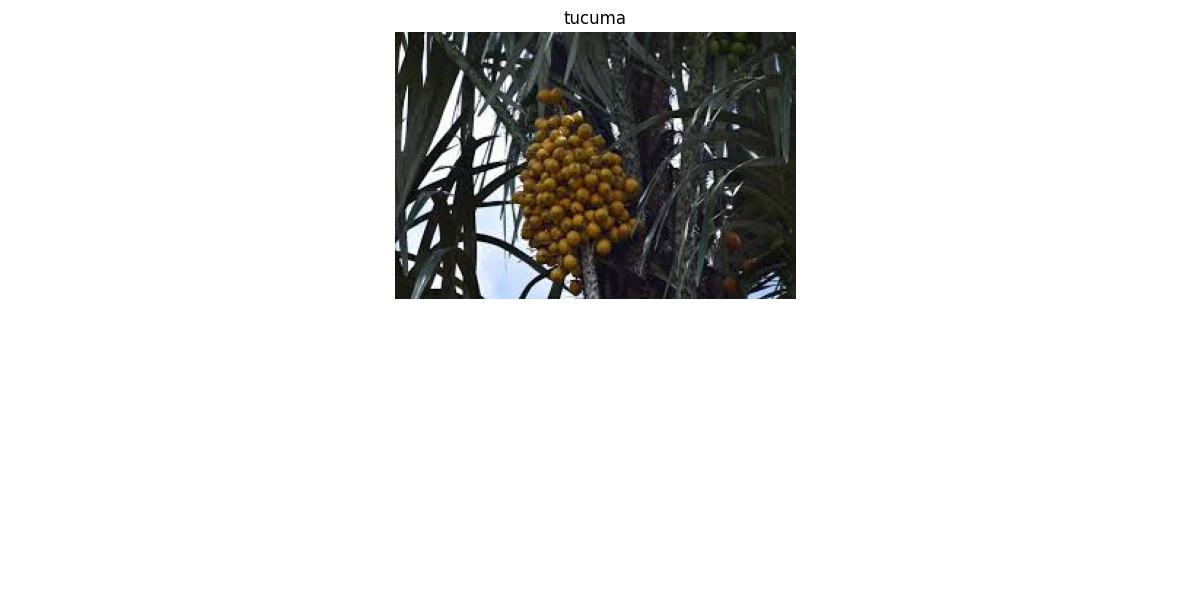

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Same directory loading
train_ds = keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_ds = keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)



Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [8]:
# Data augmentation layers (to be used inside the model)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
import numpy as np
import matplotlib.pyplot as plt
import os

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [11]:
model = keras.Sequential([

layers.Input(shape=(128,128,3)),

# Data Augmentation
data_augmentation,

# Rescaling
layers.Rescaling(1./255),

# Block 1
layers.Conv2D(32,(3,3),padding='same'),
layers.BatchNormalization(),
layers.Activation('relu'),
layers.MaxPooling2D(),
layers.Dropout(0.25),

# Block 2
layers.Conv2D(64,(3,3),padding='same'),
layers.BatchNormalization(),
layers.Activation('relu'),
layers.MaxPooling2D(),
layers.Dropout(0.25),

# Block 3
layers.Conv2D(128,(3,3),padding='same'),
layers.BatchNormalization(),
layers.Activation('relu'),
layers.MaxPooling2D(),
layers.Dropout(0.25),

# Block 4
layers.Conv2D(256,(3,3),padding='same'),
layers.BatchNormalization(),
layers.Activation('relu'),
layers.MaxPooling2D(),
layers.Dropout(0.25),

layers.Flatten(),

layers.Dense(512),
layers.BatchNormalization(),
layers.Activation('relu'),
layers.Dropout(0.5),

layers.Dense(256),
layers.BatchNormalization(),
layers.Activation('relu'),
layers.Dropout(0.5),

layers.Dense(10, activation='softmax')  # change 10 → number of classes
])

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             

 Total params: 8,916,426 (34.01 MB)

 Trainable params: 8,913,930 (34.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.1806 - loss: 2.7013 - val_accuracy: 0.1667 - val_loss: 2.2640
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.3750 - loss: 1.7745 - val_accuracy: 0.1111 - val_loss: 2.2746
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.4167 - loss: 1.7171 - val_accuracy: 0.1111 - val_loss: 2.2860
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4861 - loss: 1.5311 - val_accuracy: 0.1111 - val_loss: 2.4122
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5139 - loss: 1.4433 - val_accuracy: 0.1111 - val_loss: 2.6384
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6111 - loss: 1.2266 - val_accuracy: 0.1111 - val_loss: 2.8851
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5972 - loss: 1.3114 - val_accuracy: 0.1667 - val_loss: 3.0627
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.6806 - loss: 1.0575 - val_accuracy: 0.2222 - val_loss: 3.2793
Epoch 9/20
3

In [15]:
loss, accuracy = model.evaluate(val_ds)
print("Validation Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2222 - loss: 5.6050
Validation Accuracy: 0.2222222238779068


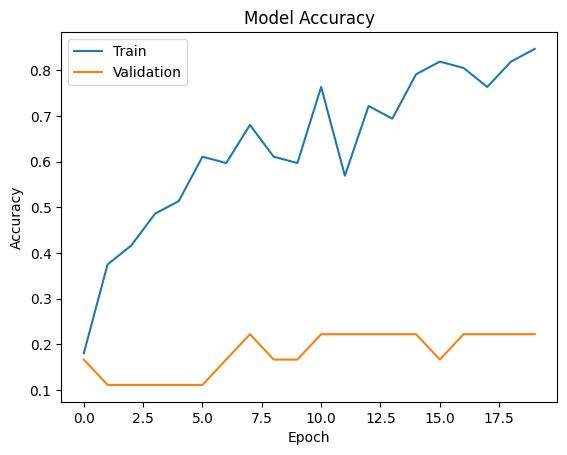

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])
plt.show()

In [17]:
model.save("cnn_model.h5")

In [18]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

In [19]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
for layer in base_model.layers:
    layer.trainable = False

In [21]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(10, activation='softmax')(x)

In [22]:
model = Model(inputs=base_model.input, outputs=x)

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.1250 - loss: 18.7597 - val_accuracy: 0.1667 - val_loss: 9.0219
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - accuracy: 0.3750 - loss: 7.8252 - val_accuracy: 0.2778 - val_loss: 8.3069
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - accuracy: 0.4861 - loss: 5.3656 - val_accuracy: 0.3889 - val_loss: 6.6202
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 7s/step - accuracy: 0.6944 - loss: 3.0425 - val_accuracy: 0.5000 - val_loss: 5.3944
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - accuracy: 0.8611 - loss: 0.9298 - val_accuracy: 0.5556 - val_loss: 4.8975
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.8750 - loss: 0.3627 - val_accuracy: 0.5556 - val_loss: 5.0850
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.8472 - loss: 1.2176 - val_accuracy: 0.5556 - val_loss: 4.9595
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 7s/step - accuracy: 0.9028 - loss: 0.7652 - val_accuracy: 0.6111 - val_loss: 5.0366
Epoch 9

In [25]:
loss, accuracy = model.evaluate(val_ds)
print("Transfer Learning Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 5.6546
Transfer Learning Accuracy: 0.5


In [26]:
predictions = model.predict(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [27]:
import numpy as np
from sklearn.metrics import classification_report

y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2
           2       0.00      0.00      0.00         3
           3       0.33      0.20      0.25         5
           4       0.25      0.25      0.25         4
           5       0.50      0.33      0.40         3

    accuracy                           0.28        18
   macro avg       0.29      0.30      0.28        18
weighted avg       0.31      0.28      0.28        18

